# Partial Supplementary Figure 5 (a, b, d, e)

#### Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.collections as mcollections
import matplotlib.colors as colors
import numpy as np
import cmocean
import processing_utils as proc_utils
import cesm2_lens_utils
import analysis_funcs as afuncs
import xesmf as xe
import pop_tools
import cftime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from scipy.stats import gaussian_kde

#### Functions

In [2]:
def calc_density_eqthermocline(lon_data, lat_data, z_data, lat_min, lat_max, lon_min, lon_max, timestart, timeend):
    lon_trunc,lat_trunc, z_trunc = lon_data, lat_data, z_data
    region_idx = get_region_lonlat(lat_trunc, lon_trunc, lat_min, lat_max, lon_min, lon_max)    
    lons_points = lon_trunc[region_idx, timestart:timeend].data.flatten()
    lats_points = lat_trunc[region_idx, timestart:timeend].data.flatten()
    f_xi, f_yi, f_zi = calc_density_sh(lons_points, lats_points)
    da = xr.DataArray(f_zi, dims=['y', 'x'],
        coords={'lon': (['y', 'x'], f_xi),'lat': (['y', 'x'], f_yi)},name='density')
    return da, region_idx, lon_trunc,lat_trunc, z_trunc

In [3]:
def compute_data(data_xarray):
    time = data_xarray.time.compute()
    lon = data_xarray.lon.compute()
    lat = data_xarray.lat.compute()
    z = data_xarray.z.compute()
    return time, lon, lat, z

In [4]:
def ocn_var_ens(ens_ind, VAR):
    COMP = 'ocn'
    DIRECTORY = f'/glade/campaign/cgd/cesm/CESM2-LE/{COMP}/proc/tseries/month_1/{VAR}/'
    ds_var_hist_var, ds_var_fut_var = cesm2_lens_utils.get_ds_var(
        directory=DIRECTORY, var=VAR, comp=COMP, index_hist = ens_ind)
    var_ds = ds_var_hist_var[VAR].sel(time=slice('1958-01', '2015-01'))
    return var_ds

In [5]:
def atm_var_ens(ens_ind, VAR):
    COMP = 'atm'
    DIRECTORY = f'/glade/campaign/cgd/cesm/CESM2-LE/{COMP}/proc/tseries/month_1/{VAR}/'
    ds_var_hist_var, ds_var_fut_var = cesm2_lens_utils.get_ds_var(
        directory=DIRECTORY, var=VAR, comp=COMP, index_hist = ens_ind)
    var_ds = ds_var_hist_var[VAR].sel(time=slice('1958-01', '2015-01')).compute()
    return var_ds

In [6]:
def plot_parcel_trajectories_w_bg(cf_data, 
                                 lon_data, lat_data, z_data,
                                 indices=None,
                                 index_min=0, index_max=300,
                                 vmin=10, vmax=30, levels=15, 
                                 cmap=cmocean.cm.thermal,
                                 line_cmap='hsv',
                                 start_color='cyan', end_color='m',
                                 xlim=(110, 290), ylim=(-60, 60),
                                 title='Parcel Trajectories',
                                 figsize=(10, 6),
                                 linewidth=1,
                                 start_size=1, end_size=1):
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Plot background
    cf = cf_data.plot.contourf(
        levels=levels, vmax=vmax, cmap=cmap, vmin=vmin, alpha=1, ax=ax
    )
    
    # Determine which indices to plot
    if indices is None:
        plot_indices = range(index_min, index_max)
    else:
        plot_indices = indices
    
    # Plot start and end points
    ax.scatter(lon_data[plot_indices, 0], lat_data[plot_indices, 0], 
               s=start_size, c=start_color, zorder=100, label='Start')
    ax.scatter(lon_data[plot_indices, -1], lat_data[plot_indices, -1], 
               s=end_size, c=end_color, zorder=100, label='End')
        
    # Plot trajectories
    for i in plot_indices:
        lon = lon_data.isel(trajectory=i).values
        lat = lat_data.isel(trajectory=i).values
        depth = z_data.isel(trajectory=i).values
        
        points = np.array([lon, lat]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        
        lc = mcollections.LineCollection(
            segments, cmap=line_cmap, norm=plt.Normalize(depth.min(), depth.max()), linewidth=linewidth
        )
        lc.set_array(depth[:-1])
        ax.add_collection(lc)
    
    # Add reference lines
    ax.axhline(y=5, c='k', linestyle='dotted', alpha=0.7)
    ax.axhline(y=0, c='k', linestyle='dashed', alpha=0.7)
    ax.axhline(y=-5, c='k', linestyle='dotted', alpha=0.7)
    
    # Formatting
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.tick_params(labelsize=12)
    ax.grid(c='k', linestyle='dashed', alpha=0.2)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_title(title, fontsize=15)
    
    # Add colorbar for trajectories
    sm = plt.cm.ScalarMappable(cmap=line_cmap, norm=plt.Normalize(depth.min(), depth.max()))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label='Depth')
    cbar.ax.tick_params(labelsize=12)
    
    plt.tight_layout()
    return fig, ax

In [7]:
def truncate_lonlatz(lon_data, lat_data, z_data):
    lon_data_truncated = lon_data.copy()
    lat_data_truncated = lat_data.copy()
    z_data_truncated = z_data.copy()
    
    # lon_min, lon_max = 260, 291
    lon_min, lon_max = 260, 280#290, 291 #260, 280
    lat_min, lat_max = -1, 1
    
    for i in range(lon_data.sizes['trajectory']):
        lon_traj = lon_data.isel(trajectory=i).values
        lat_traj = lat_data.isel(trajectory=i).values
        
        in_target_region = (lon_traj >= lon_min) & (lon_traj <= lon_max) & (lat_traj >= lat_min) & (lat_traj <= lat_max)
        
        # Find first occurrence in target region
        region_indices = np.where(in_target_region)[0]
        
        if len(region_indices) > 0:
            first_in_region = region_indices[0]
            # Set all observations after entering region to NaN
            lon_data_truncated[i, first_in_region+1:] = np.nan
            lat_data_truncated[i, first_in_region+1:] = np.nan
            z_data_truncated[i, first_in_region+1:] = np.nan

    return lon_data_truncated, lat_data_truncated, z_data_truncated

####################
# lon_data_truncated = lon_data.copy()
# lat_data_truncated = lat_data.copy()
# z_data_truncated = z_data.copy()

# lon_min, lon_max = 240, 280
# lat_min, lat_max = -1, 1

# for i in range(lsh_lon.sizes['trajectory']):
#     lon_traj = lsh_lon.isel(trajectory=i).values
#     lat_traj = lsh_lat.isel(trajectory=i).values
    
#     in_target_region = (lon_traj >= lon_min) & (lon_traj <= lon_max) & (lat_traj >= lat_min) & (lat_traj <= lat_max)
    
#     # Find first occurrence in target region
#     region_indices = np.where(in_target_region)[0]
    
#     if len(region_indices) > 0:
#         first_in_region = region_indices[0]
#         # Set all observations after entering region to NaN
#         lon_data_truncated[i, first_in_region+1:] = np.nan
#         lat_data_truncated[i, first_in_region+1:] = np.nan
#         z_data_truncated[i, first_in_region+1:] = np.nan

In [8]:
# original working
def truncate_after_exit_equator(lon_data, lat_data, z_data):
    lon_data_truncated = lon_data.copy()
    lat_data_truncated = lat_data.copy()
    z_data_truncated = z_data.copy()
    
    # Define equatorial region boundaries
    lat_min, lat_max = -0.5, 0.5     # 2°S to 2°N
    lon_min, lon_max = 140, 305   # 200° to 280° longitude
    
    for i in range(lon_data.sizes['trajectory']):
        lon_traj = lon_data.isel(trajectory=i).values
        lat_traj = lat_data.isel(trajectory=i).values
        
        # Find where trajectory is within equatorial region (both lat and lon constraints)
        in_equator = ((lat_traj >= lat_min) & (lat_traj <= lat_max) & 
                      (lon_traj >= lon_min) & (lon_traj <= lon_max))
        
        # Find the last time the trajectory is in the equatorial region
        equator_indices = np.where(in_equator)[0]
        
        if len(equator_indices) > 0:
            last_in_equator = equator_indices[-1]
            
            # Find the first point AFTER last_in_equator that exits the equatorial region
            exit_found = False
            for j in range(last_in_equator + 1, len(lat_traj)):
                # Check if point is outside equatorial region (either lat or lon constraint violated)
                if (lat_traj[j] < lat_min or lat_traj[j] > lat_max or 
                    lon_traj[j] < lon_min or lon_traj[j] > lon_max):
                    # Truncate from this exit point onward
                    lon_data_truncated[i, j:] = np.nan
                    lat_data_truncated[i, j:] = np.nan
                    z_data_truncated[i, j:] = np.nan
                    exit_found = True
                    break
            
            # If trajectory ends while still in equatorial region, no truncation needed
            # (no action needed in this case)

    return lon_data_truncated, lat_data_truncated, z_data_truncated

In [9]:
def truncate_after_first_exit_equator(lon_data, lat_data, z_data):
    lon_data_truncated = lon_data.copy()
    lat_data_truncated = lat_data.copy()
    z_data_truncated = z_data.copy()
    
    # Define equatorial region boundaries
    lat_min, lat_max = -1, 1     # 2°S to 2°N
    lon_min, lon_max = 140, 305   # 200° to 280° longitude
    
    for i in range(lon_data.sizes['trajectory']):
        lon_traj = lon_data.isel(trajectory=i).values
        lat_traj = lat_data.isel(trajectory=i).values
        
        # Track if we've entered the equatorial region at least once
        has_entered_equator = False
        first_exit_index = None
        
        for j in range(len(lat_traj)):
            # Check if current point is in equatorial region
            in_equator = ((lat_traj[j] >= lat_min) & (lat_traj[j] <= lat_max) & 
                          (lon_traj[j] >= lon_min) & (lon_traj[j] <= lon_max))
            
            if in_equator:
                has_entered_equator = True
            elif has_entered_equator and first_exit_index is None:
                # We've entered equator before and now we're exiting for the first time
                first_exit_index = j
                break
        
        # Truncate after first exit point
        if first_exit_index is not None:
            lon_data_truncated[i, first_exit_index:] = np.nan
            lat_data_truncated[i, first_exit_index:] = np.nan
            z_data_truncated[i, first_exit_index:] = np.nan
       #     print(f"Trajectory {i}: first exit at index {first_exit_index}")
       # elif has_entered_equator:
      #      print(f"Trajectory {i}: entered equator but never exited")
      #  else:
      #      print(f"Trajectory {i}: never entered equator")

    return lon_data_truncated, lat_data_truncated, z_data_truncated

In [10]:
def get_region_lonlat(lat_data, lon_data, region_lat_min, region_lat_max, region_lon_min, region_lon_max):
    index_min = 0
    index_max = 400
    
    in_region_mask = (
        (lat_data[index_min:index_max, 0] >= region_lat_min) & 
        (lat_data[index_min:index_max, 0] <= region_lat_max) &
        (lon_data[index_min:index_max, 0] >= region_lon_min) & 
        (lon_data[index_min:index_max, 0] <= region_lon_max)
    )
    
    region_indices = np.where(in_region_mask)[0] + index_min
    return region_indices

In [11]:
def calc_density_sh(lons_points, lats_points):
    
    lon_trunc,lat_trunc, z_trunc = truncate_lonlatz(
        lon_data, lat_data, z_data)

    region_idx_p1 = get_region_lonlat(lat_trunc, lon_trunc, -30, -20, 240, 270)
    region_idx_p2 = get_region_lonlat(lat_trunc, lon_trunc, -50, -30, 180, 270)
    
    lons_points = lon_trunc[np.append(region_idx_p1, region_idx_p2), :].data.flatten()
    lats_points = lat_trunc[np.append(region_idx_p1, region_idx_p2), :].data.flatten()
    
    non_nan_mask = ~np.isnan(lons_points)
    cleaned_lats_points = lats_points[non_nan_mask]
    cleaned_lons_points = lons_points[non_nan_mask]
    
    x = cleaned_lons_points
    y = cleaned_lats_points
    k = gaussian_kde(np.vstack([x, y]))

    num_bins_x = 200
    num_bins_y = 200
    
    xi = np.linspace(x.min(), x.max(), num_bins_x)
    yi = np.linspace(y.min(), y.max(), num_bins_y)
    xi, yi = np.meshgrid(xi, yi)
    
    zi = k(np.vstack([xi.flatten(), yi.flatten()]))
    zi = zi.reshape(xi.shape)
    return xi, yi, zi

In [12]:
def calc_density(lon_data, lat_data, z_data, lat_min, lat_max, lon_min, lon_max, timestart, timeend):
    
    lon_trunc,lat_trunc, z_trunc = truncate_after_first_exit_equator(#truncate_after_exit_equator(#truncate_lonlatz(
        lon_data, lat_data, z_data)

    region_idx = get_region_lonlat(lat_trunc, lon_trunc, lat_min, lat_max, lon_min, lon_max)
    # region_idx_p1 = get_region_lonlat(lat_trunc, lon_trunc, -35, -30, 220, 240)
    # region_idx_p2 = get_region_lonlat(lat_trunc, lon_trunc, -40, -35, 220,240)
    
    lons_points = lon_trunc[region_idx, timestart:timeend].data.flatten()
    lats_points = lat_trunc[region_idx, timestart:timeend].data.flatten()
    
    f_xi, f_yi, f_zi = calc_density_sh(lons_points, lats_points)
    
    da = xr.DataArray(f_zi, dims=['y', 'x'],
        coords={'lon': (['y', 'x'], f_xi),'lat': (['y', 'x'], f_yi)},name='density')
    
    # da_nan = xr.where(da <= 0.000001, np.nan, da)
    # return da_nan, region_idx, lon_trunc,lat_trunc, z_trunc
    return da, region_idx, lon_trunc,lat_trunc, z_trunc

In [13]:
def calc_density_sh(lons, lats, gridsize=100, bw_method=None, lon_bounds=(110, 305), lat_bounds=(-50, 50)):
    """
    Calculate 2D Gaussian KDE density with fixed grid bounds.
    """
    # Remove NaN values
    valid_mask = ~np.isnan(lons) & ~np.isnan(lats)
    lons_clean = lons[valid_mask]
    lats_clean = lats[valid_mask]
    
    if len(lons_clean) == 0:
        raise ValueError("No valid data points for KDE calculation")
    
    # Use fixed bounds instead of data-derived bounds
    xi = np.linspace(lon_bounds[0], lon_bounds[1], gridsize)
    yi = np.linspace(lat_bounds[0], lat_bounds[1], gridsize)
    f_xi, f_yi = np.meshgrid(xi, yi)
    
    # Calculate Gaussian KDE
    coordinates = np.vstack([lons_clean, lats_clean])
    kde = gaussian_kde(coordinates, bw_method=bw_method)
    
    # Evaluate KDE on the fixed grid
    grid_coords = np.vstack([f_xi.ravel(), f_yi.ravel()])
    f_zi = kde(grid_coords).reshape(f_xi.shape)
    
    return f_xi, f_yi, f_zi

# def calc_density(lon_data, lat_data, z_data, lat_min, lat_max, lon_min, lon_max, timestart, timeend):
    
#     lon_trunc, lat_trunc, z_trunc = truncate_lonlatz(lon_data, lat_data, z_data)

#     region_idx = get_region_lonlat(lat_trunc, lon_trunc, lat_min, lat_max, lon_min, lon_max)
    
#     lons_points = lon_trunc[region_idx, timestart:timeend].data.flatten()
#     lats_points = lat_trunc[region_idx, timestart:timeend].data.flatten()
    
#     # Use fixed grid bounds that match your plot extent (140-284°E, -40-40°N)
#     f_xi, f_yi, f_zi = calc_density_sh(lons_points, lats_points, 
#                                       lon_bounds=(110, 305), 
#                                       lat_bounds=(-50, 50))
    
#     da = xr.DataArray(f_zi, dims=['y', 'x'],
#         coords={'lon': (['y', 'x'], f_xi), 'lat': (['y', 'x'], f_yi)}, name='density')
    
#     da_nan = xr.where(da <= 0.000001, np.nan, da)
#     return da_nan, region_idx

In [14]:
def find_sigma_theta_points(lsh_lon, lsh_lat, sigma_theta_pd, num_points=400, sigma_min=24.4, sigma_max=24.8):
    """
    Find indices of points within specified sigma theta range.
    
    Parameters:
    -----------
    lsh_lon, lsh_lat : array
        Longitude and latitude arrays
    sigma_theta_pd : xarray.DataArray
        Sigma theta data
    num_points : int
        Number of points to check
    sigma_min, sigma_max : float
        Sigma theta range to filter
    
    Returns:
    --------
    yellow_indices : list
        Indices of points within the sigma theta range
    """
    yellow_indices = []
    
    for i in range(num_points):
        lon = lsh_lon[i, 0]
        lat = lsh_lat[i, 0]
        
        try:
            sigma_val = sigma_theta_pd.sel(lon=lon, lat=lat, method='nearest').values
        except:
            try:
                sigma_val = sigma_theta_pd.interp(lon=lon, lat=lat).values
            except:
                lon_idx = np.argmin(np.abs(sigma_theta_pd.lon.values - lon))
                lat_idx = np.argmin(np.abs(sigma_theta_pd.lat.values - lat))
                sigma_val = sigma_theta_pd.values[lat_idx, lon_idx]
        
        if sigma_min <= sigma_val <= sigma_max:
            yellow_indices.append(i)
    
    return yellow_indices

In [15]:
def spatial_lens_SH_map_w_traj(lon_data, lat_data, z_data, region_idx, da_selected, ENS_MEMB, INIT_DEPTH):
    fig, ax = plt.subplots(figsize=(5, 4),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
    ####### STATICS
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
    ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
    ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
    ax.set_extent([120, 284, -50, 10], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                      zorder=4, linestyle='--', alpha=0.5)
    gl.xlabel_style = {'size': 12}  # Longitude labels
    gl.ylabel_style = {'size': 12}  # Latitude labels
    ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
    ax.spines['geo'].set_edgecolor('black')
    ax.spines['geo'].set_linewidth(1.5)
    ax.set_aspect('auto')
    
    ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
               s=0.5, c='m', marker='o', edgecolor='m', zorder=100,transform=ccrs.PlateCarree())

    #### TRAJECTORIES
    for i in region_idx[:]:
        lon = lon_data.isel(trajectory=i).values
        lat = lat_data.isel(trajectory=i).values
        depth = z_data.isel(trajectory=i).values
        points = np.array([lon, lat]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = mcollections.LineCollection(
                segments, cmap='jet', norm=plt.Normalize(0, 25000), 
                linewidth=1., alpha=1, transform=ccrs.PlateCarree())
        lc.set_array(depth[:-1])
        ax.add_collection(lc)
    
    #### CONTOURF AND CONTOUR
    contourf_plot = da_selected.plot.contourf(
        x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
        levels=21, vmax=80.5e-5, vmin=0.5e-5, alpha=1)
    
    da_selected.plot.contour(
        x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=0.5,
        levels=[2e-5, 5e-5, 10e-5, 15e-5, 20e-5, 25e-5], alpha=1)
    
    #### COLORBAR
    density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0.5e-5, 80.5e-5))
    density_sm.set_array([])
    density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
    density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
    tick_values = np.arange(0, 80, 20)  # This gives 5, 10, 15, 20, 25, 30
    density_cbar.set_ticks(tick_values * 1e-5)
    density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
    density_cbar.ax.tick_params(labelsize=12)
    
    #### TITLE
    plt.title('{} LENS begin at {}m'.format(ENS_MEMB, INIT_DEPTH), fontsize=12, fontweight='bold', zorder=12, loc='left')
    plt.show()

In [16]:
def spatial_lens_NH_map_w_traj(lon_data, lat_data, z_data, region_idx, da_selected, ENS_MEMB, INIT_DEPTH):
    fig, ax = plt.subplots(figsize=(5, 4),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
    ####### STATICS
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
    ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
    ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
    ax.set_extent([120, 284, -10, 50], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                      zorder=4, linestyle='--', alpha=0.5)
    gl.xlabel_style = {'size': 12}  # Longitude labels
    gl.ylabel_style = {'size': 12}  # Latitude labels
    ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
    ax.spines['geo'].set_edgecolor('black')
    ax.spines['geo'].set_linewidth(1.5)
    ax.set_aspect('auto')
    
    ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
               s=0.5, c='m', marker='o', edgecolor='m', zorder=100,transform=ccrs.PlateCarree())

    #### TRAJECTORIES
    for i in region_idx[::2]:
        lon = lon_data.isel(trajectory=i).values
        lat = lat_data.isel(trajectory=i).values
        depth = z_data.isel(trajectory=i).values
        points = np.array([lon, lat]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = mcollections.LineCollection(
                segments, cmap='jet', norm=plt.Normalize(0, 25000), 
                linewidth=1., alpha=1, transform=ccrs.PlateCarree())
        lc.set_array(depth[:-1])
        ax.add_collection(lc)
    
    #### CONTOURF AND CONTOUR
    contourf_plot = da_selected.plot.contourf(
        x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
        levels=21, vmax=40.5e-5, vmin=0.5e-5, alpha=1)
    
    da_selected.plot.contour(
        x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=0.5,
        levels=[2e-5, 5e-5, 10e-5, 15e-5, 20e-5, 25e-5], alpha=1)
    
    #### COLORBAR
    density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0.5e-5, 40.5e-5))
    density_sm.set_array([])
    density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
    density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
    tick_values = np.arange(0, 50, 10)  # This gives 5, 10, 15, 20, 25, 30
    density_cbar.set_ticks(tick_values * 1e-5)
    density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
    density_cbar.ax.tick_params(labelsize=12)
    
    #### TITLE
    plt.title('{} LENS begin at {}m'.format(ENS_MEMB, INIT_DEPTH), fontsize=12, fontweight='bold', zorder=12, loc='left')
    plt.show()

In [17]:
def spatial_lens_SH_map_no_traj(lon_data, lat_data, z_data, region_idx, da_selected, ENS_MEMB, INIT_DEPTH):
    fig, ax = plt.subplots(figsize=(5, 4),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
    ####### STATICS
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
    ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
    ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
    ax.set_extent([120, 284, -50, 10], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                      zorder=4, linestyle='--', alpha=0.5)
    gl.xlabel_style = {'size': 12}  # Longitude labels
    gl.ylabel_style = {'size': 12}  # Latitude labels
    ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
    ax.spines['geo'].set_edgecolor('black')
    ax.spines['geo'].set_linewidth(1.5)
    ax.set_aspect('auto')
    
    ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
               s=0.5, c='m', marker='o', edgecolor='m', zorder=100,transform=ccrs.PlateCarree())

    #### CONTOURF AND CONTOUR
    contourf_plot = da_selected.plot.contourf(
        x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
        levels=21, vmax=80.5e-5, vmin=0.5e-5, alpha=1)
    
    da_selected.plot.contour(
        x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=0.5,
        levels=[2e-5, 5e-5, 10e-5, 15e-5, 20e-5, 25e-5], alpha=1)
    
    #### COLORBAR
    density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0.5e-5, 80.5e-5))
    density_sm.set_array([])
    density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
    density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
    tick_values = np.arange(0, 80, 20)  # This gives 5, 10, 15, 20, 25, 30
    density_cbar.set_ticks(tick_values * 1e-5)
    density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
    density_cbar.ax.tick_params(labelsize=12)
    
    #### TITLE
    plt.title('{} LENS begin at {}m'.format(ENS_MEMB, INIT_DEPTH), fontsize=12, fontweight='bold', zorder=12, loc='left')
    plt.show()

In [18]:
def spatial_lens_NH_map_no_traj(lon_data, lat_data, z_data, region_idx, da_selected, ENS_MEMB, INIT_DEPTH):
    fig, ax = plt.subplots(figsize=(5, 4),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
    ####### STATICS
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
    ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
    ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
    ax.set_extent([120, 284, -10, 50], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                      zorder=4, linestyle='--', alpha=0.5)
    gl.xlabel_style = {'size': 12}  # Longitude labels
    gl.ylabel_style = {'size': 12}  # Latitude labels
    ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
    ax.spines['geo'].set_edgecolor('black')
    ax.spines['geo'].set_linewidth(1.5)
    ax.set_aspect('auto')
    
    ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
               s=0.5, c='m', marker='o', edgecolor='m', zorder=100,transform=ccrs.PlateCarree())

    #### CONTOURF AND CONTOUR
    contourf_plot = da_selected.plot.contourf(
        x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
        levels=21, vmax=40.5e-5, vmin=0.5e-5, alpha=1)
    
    da_selected.plot.contour(
        x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=0.5,
        levels=[2e-5, 5e-5, 10e-5, 15e-5, 20e-5, 25e-5], alpha=1)
    
    #### COLORBAR
    density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0.5e-5, 40.5e-5))
    density_sm.set_array([])
    density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
    density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
    tick_values = np.arange(0, 50, 10)  # This gives 5, 10, 15, 20, 25, 30
    density_cbar.set_ticks(tick_values * 1e-5)
    density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
    density_cbar.ax.tick_params(labelsize=12)
    
    #### TITLE
    plt.title('{} LENS begin at {}m'.format(ENS_MEMB, INIT_DEPTH), fontsize=12, fontweight='bold', zorder=12, loc='left')
    plt.show()

In [19]:
def spatial_fosi_SH_map_no_traj(lon_data, lat_data, z_data, region_idx, da_selected, INIT_DEPTH):
    fig, ax = plt.subplots(figsize=(5, 4),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
    ####### STATICS
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
    ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
    ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
    ax.set_extent([120, 284, -50, 10], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                      zorder=4, linestyle='--', alpha=0.5)
    gl.xlabel_style = {'size': 12}  # Longitude labels
    gl.ylabel_style = {'size': 12}  # Latitude labels
    ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
    ax.spines['geo'].set_edgecolor('black')
    ax.spines['geo'].set_linewidth(1.5)
    ax.set_aspect('auto')
    
    ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
               s=0.5, c='m', marker='o', edgecolor='m', zorder=100,transform=ccrs.PlateCarree())

    #### CONTOURF AND CONTOUR
    contourf_plot = da_selected.plot.contourf(
        x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
        levels=21, vmax=80.5e-5, vmin=0.5e-5, alpha=1)
    
    da_selected.plot.contour(
        x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=0.5,
        levels=[2e-5, 5e-5, 10e-5, 15e-5, 20e-5, 25e-5], alpha=1)
    
    #### COLORBAR
    density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0.5e-5, 80.5e-5))
    density_sm.set_array([])
    density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
    density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
    tick_values = np.arange(0, 80, 20)  # This gives 5, 10, 15, 20, 25, 30
    density_cbar.set_ticks(tick_values * 1e-5)
    density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
    density_cbar.ax.tick_params(labelsize=12)
    
    #### TITLE
    plt.title('FOSI begin at {}m'.format(INIT_DEPTH), fontsize=12, fontweight='bold', zorder=12, loc='left')
    plt.show()

In [20]:
def spatial_fosi_NH_map_no_traj(lon_data, lat_data, z_data, region_idx, da_selected, INIT_DEPTH):
    fig, ax = plt.subplots(figsize=(5, 4),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
    ####### STATICS
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
    ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
    ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
    ax.set_extent([120, 284, -10, 50], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                      zorder=4, linestyle='--', alpha=0.5)
    gl.xlabel_style = {'size': 12}  # Longitude labels
    gl.ylabel_style = {'size': 12}  # Latitude labels
    ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
    ax.spines['geo'].set_edgecolor('black')
    ax.spines['geo'].set_linewidth(1.5)
    ax.set_aspect('auto')
    
    ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
               s=0.5, c='m', marker='o', edgecolor='m', zorder=100,transform=ccrs.PlateCarree())

    #### CONTOURF AND CONTOUR
    contourf_plot = da_selected.plot.contourf(
        x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
        levels=21, vmax=40.5e-5, vmin=0.5e-5, alpha=1)
    
    da_selected.plot.contour(
        x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=0.5,
        levels=[2e-5, 5e-5, 10e-5, 15e-5, 20e-5, 25e-5], alpha=1)
    
    #### COLORBAR
    density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0.5e-5, 40.5e-5))
    density_sm.set_array([])
    density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
    density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
    tick_values = np.arange(0, 50, 10)  # This gives 5, 10, 15, 20, 25, 30
    density_cbar.set_ticks(tick_values * 1e-5)
    density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
    density_cbar.ax.tick_params(labelsize=12)
    
    #### TITLE
    plt.title('FOSI begin at {}m'.format(INIT_DEPTH), fontsize=12, fontweight='bold', zorder=12, loc='left')
    plt.show()

In [21]:
def spatial_fosi_SH_map_w_traj(lon_data, lat_data, z_data, region_idx, da_selected, INIT_DEPTH):
    fig, ax = plt.subplots(figsize=(5, 4),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
    ####### STATICS
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
    ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
    ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
    ax.set_extent([120, 284, -50, 10], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                      zorder=4, linestyle='--', alpha=0.5)
    gl.xlabel_style = {'size': 12}  # Longitude labels
    gl.ylabel_style = {'size': 12}  # Latitude labels
    ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
    ax.spines['geo'].set_edgecolor('black')
    ax.spines['geo'].set_linewidth(1.5)
    ax.set_aspect('auto')
    
    ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
               s=0.5, c='m', marker='o', edgecolor='m', zorder=100,transform=ccrs.PlateCarree())

    #### TRAJECTORIES
    for i in region_idx[:]:
        lon = lon_data.isel(trajectory=i).values
        lat = lat_data.isel(trajectory=i).values
        depth = z_data.isel(trajectory=i).values
        points = np.array([lon, lat]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = mcollections.LineCollection(
                segments, cmap='jet', norm=plt.Normalize(0, 25000), 
                linewidth=1., alpha=1, transform=ccrs.PlateCarree())
        lc.set_array(depth[:-1])
        ax.add_collection(lc)
    
    #### CONTOURF AND CONTOUR
    contourf_plot = da_selected.plot.contourf(
        x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
        levels=21, vmax=80.5e-5, vmin=0.5e-5, alpha=1)
    
    da_selected.plot.contour(
        x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=0.5,
        levels=[2e-5, 5e-5, 10e-5, 15e-5, 20e-5, 25e-5], alpha=1)
    
    #### COLORBAR
    density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0.5e-5, 80.5e-5))
    density_sm.set_array([])
    density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
    density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
    tick_values = np.arange(0, 80, 20)  # This gives 5, 10, 15, 20, 25, 30
    density_cbar.set_ticks(tick_values * 1e-5)
    density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
    density_cbar.ax.tick_params(labelsize=12)
    
    #### TITLE
    plt.title('FOSI begin at {}m'.format(INIT_DEPTH), fontsize=12, fontweight='bold', zorder=12, loc='left')
    plt.show()

In [22]:
def spatial_fosi_NH_map_w_traj(lon_data, lat_data, z_data, region_idx, da_selected, INIT_DEPTH):
    fig, ax = plt.subplots(figsize=(5, 4),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
    ####### STATICS
    ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
    ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
    ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
    ax.set_extent([120, 284, -10, 50], crs=ccrs.PlateCarree())
    gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                      zorder=4, linestyle='--', alpha=0.5)
    gl.xlabel_style = {'size': 12}  # Longitude labels
    gl.ylabel_style = {'size': 12}  # Latitude labels
    ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
    ax.spines['geo'].set_edgecolor('black')
    ax.spines['geo'].set_linewidth(1.5)
    ax.set_aspect('auto')
    
    ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
               s=0.5, c='m', marker='o', edgecolor='m', zorder=100,transform=ccrs.PlateCarree())

    #### TRAJECTORIES
    for i in region_idx[::2]:
        lon = lon_data.isel(trajectory=i).values
        lat = lat_data.isel(trajectory=i).values
        depth = z_data.isel(trajectory=i).values
        points = np.array([lon, lat]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        lc = mcollections.LineCollection(
                segments, cmap='jet', norm=plt.Normalize(0, 25000), 
                linewidth=1., alpha=1, transform=ccrs.PlateCarree())
        lc.set_array(depth[:-1])
        ax.add_collection(lc)
    
    #### CONTOURF AND CONTOUR
    contourf_plot = da_selected.plot.contourf(
        x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
        levels=21, vmax=40.5e-5, vmin=0.5e-5, alpha=1)
    
    da_selected.plot.contour(
        x='lon', y='lat', transform=ccrs.PlateCarree(), colors='k', linewidths=0.5,
        levels=[2e-5, 5e-5, 10e-5, 15e-5, 20e-5, 25e-5], alpha=1)
    
    #### COLORBAR
    density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0.5e-5, 40.5e-5))
    density_sm.set_array([])
    density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
    density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
    tick_values = np.arange(0, 50, 10)  # This gives 5, 10, 15, 20, 25, 30
    density_cbar.set_ticks(tick_values * 1e-5)
    density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
    density_cbar.ax.tick_params(labelsize=12)
    
    #### TITLE
    plt.title('FOSI begin at {}m'.format(INIT_DEPTH), fontsize=12, fontweight='bold', zorder=12, loc='left')
    plt.show()

# North/South Pacific: Parcel trajectories

In [23]:
INIT_DEPTH = 50

file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_fosi_SH_startingat{}m_1958_1977.zarr'.format(
    INIT_DEPTH)

fosi_pt = xr.open_zarr(file_path)
f_time, f_lon, f_lat, f_z = compute_data(fosi_pt)

### SOUTH PACIFIC
da_f, region_idx_f,lon_trunc_f,lat_trunc_f, z_trunc_f = calc_density(
   lon_data=f_lon, lat_data=f_lat, z_data=f_z, 
    lat_min=-40, lat_max=-30, lon_min=215, lon_max=275, # 220 to 240
    # timestart=0, timeend=244)
    timestart=244-61, timeend=244)

# #### NORTH PACIFIC
# da_f, region_idx_f, lon_trunc_f,lat_trunc_f, z_trunc_f = calc_density(
#    lon_data=f_lon, lat_data=f_lat, z_data=f_z, 
#     lat_min=38, lat_max=45, 
#     lon_min=140, lon_max=210,
#     timestart=244-61, timeend=244)

In [71]:
# ============================================================
# FOSI - 2°S threshold, 160°E WBC/interior boundary
# ============================================================
sh_lats_f = lat_trunc_f.isel(trajectory=region_idx_f)
sh_lons_f = lon_trunc_f.isel(trajectory=region_idx_f)

wbc_count_f = 0
interior_count_f = 0

for i in range(len(region_idx_f)):
    lat_traj = sh_lats_f.isel(trajectory=i).values
    lon_traj = sh_lons_f.isel(trajectory=i).values
    cross = np.where(lat_traj >= -2)[0]
    if len(cross) > 0:
        first = cross[0]
        if lon_traj[first] <= 160:
            wbc_count_f += 1
        else:
            interior_count_f += 1

frac_fosi = (wbc_count_f + interior_count_f) / 60
print(f"FOSI total:    {wbc_count_f + interior_count_f}/60 = {frac_fosi*100:.1f}%")
print(f"FOSI WBC:      {wbc_count_f}/60 = {wbc_count_f/60*100:.1f}%")
print(f"FOSI Interior: {interior_count_f}/60 = {interior_count_f/60*100:.1f}%")

# ============================================================
# LENS - 2°S threshold, 160°E WBC/interior boundary
# ============================================================
fracs_lens = []
wbc_lens = []
interior_lens = []

for i, ENS_MEMB in enumerate(ENS_MEMBERS_LIST):
    lat_l = lat_trunc_list[i]
    lon_l = lon_trunc_list[i]
    region_idx_l = region_indx_list[i]
    n_particles = len(region_idx_l)

    sh_lats_l = lat_l.isel(trajectory=region_idx_l)
    sh_lons_l = lon_l.isel(trajectory=region_idx_l)

    reaches = (sh_lats_l >= -2).any(dim='obs')
    frac = reaches.sum().values / n_particles
    fracs_lens.append(frac)

    wbc_count = 0
    interior_count = 0
    for j in range(n_particles):
        lat_traj = sh_lats_l.isel(trajectory=j).values
        lon_traj = sh_lons_l.isel(trajectory=j).values
        cross = np.where(lat_traj >= -2)[0]
        if len(cross) > 0:
            first = cross[0]
            if lon_traj[first] <= 160:
                wbc_count += 1
            else:
                interior_count += 1

    wbc_lens.append(wbc_count / n_particles)
    interior_lens.append(interior_count / n_particles)
    print(f"Member {ENS_MEMB:3d}: {reaches.sum().values:2d}/{n_particles} ({frac*100:.1f}%) — WBC: {wbc_count} ({wbc_count/n_particles*100:.1f}%), Interior: {interior_count} ({interior_count/n_particles*100:.1f}%)")

fracs_lens = np.array(fracs_lens)
wbc_lens   = np.array(wbc_lens)
interior_lens = np.array(interior_lens)

# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*60}")
print(f"FOSI total:    {frac_fosi*100:.1f}%")
print(f"LENS total:    {fracs_lens.mean()*100:.1f}% ± {fracs_lens.std()*100:.1f}%")
print(f"\nFOSI WBC:      {wbc_count_f/60*100:.1f}%")
print(f"LENS WBC:      {wbc_lens.mean()*100:.1f}% ± {wbc_lens.std()*100:.1f}%")
print(f"\nFOSI Interior: {interior_count_f/60*100:.1f}%")
print(f"LENS Interior: {interior_lens.mean()*100:.1f}% ± {interior_lens.std()*100:.1f}%")

FOSI total:    47/60 = 78.3%
FOSI WBC:      41/60 = 68.3%
FOSI Interior: 6/60 = 10.0%
Member   0: 38/60 (63.3%) — WBC: 38 (63.3%), Interior: 0 (0.0%)
Member  65: 42/60 (70.0%) — WBC: 39 (65.0%), Interior: 3 (5.0%)
Member  32: 39/60 (65.0%) — WBC: 36 (60.0%), Interior: 3 (5.0%)
Member  85: 39/60 (65.0%) — WBC: 38 (63.3%), Interior: 1 (1.7%)
Member  61: 41/60 (68.3%) — WBC: 40 (66.7%), Interior: 1 (1.7%)
Member  90: 41/60 (68.3%) — WBC: 41 (68.3%), Interior: 0 (0.0%)
Member  80: 26/60 (43.3%) — WBC: 24 (40.0%), Interior: 2 (3.3%)
Member  68: 42/60 (70.0%) — WBC: 39 (65.0%), Interior: 3 (5.0%)
Member  73: 37/60 (61.7%) — WBC: 34 (56.7%), Interior: 3 (5.0%)
Member  49: 41/60 (68.3%) — WBC: 37 (61.7%), Interior: 4 (6.7%)

FOSI total:    78.3%
LENS total:    64.3% ± 7.5%

FOSI WBC:      68.3%
LENS WBC:      61.0% ± 7.7%

FOSI Interior: 10.0%
LENS Interior: 3.3% ± 2.2%


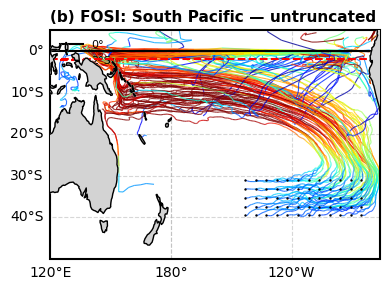

In [68]:
fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})

ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}
gl.ylabel_style = {'size': 10, 'color':'k'}

# Both latitude lines
ax.axhline(y=0,  color='k', linestyle='-',  linewidth=1.5, zorder=6, label='0°')
ax.axhline(y=-2, color='r', linestyle='--', linewidth=1.5, zorder=6, label='2°S')

ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

# Initial locations — use raw data
ax.scatter(lon_f_raw.isel(trajectory=region_idx_f_raw, obs=0),
           lat_f_raw.isel(trajectory=region_idx_f_raw, obs=0),
           s=0.5, c='k', marker='o', zorder=100, transform=ccrs.PlateCarree())

# Untruncated trajectories
for i in region_idx_f_raw:
    lon  = lon_f_raw.isel(trajectory=i).values
    lat  = lat_f_raw.isel(trajectory=i).values
    dep  = z_f_raw.isel(trajectory=i).values
    points   = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
        segments, cmap='jet', norm=plt.Normalize(0, 25000),
        linewidth=.8, alpha=0.8, transform=ccrs.PlateCarree())
    lc.set_array(dep[:-1])
    ax.add_collection(lc)

ax.legend(loc='upper left', fontsize=8, frameon=False)
plt.title('(b) FOSI: South Pacific — untruncated', fontsize=11, fontweight='bold', loc='left')
plt.tight_layout()
plt.show()

In [27]:
FOSI_pd_obs_array = np.load('/glade/derecho/scratch/cassiacai/FOSI_SH_traj_PD_fullarray.npy')

In [28]:
# For FOSI
print(lon_trunc_f.dims)
print(lon_trunc_f.shape)  # expecting (trajectory, time)?

# How do you define "reaches the equator"?
# Is it particles that cross lat=0 at any point?
print(lat_trunc_f.min())  # do any go to 0 or above?

# What does region_idx_f contain?
print(region_idx_f)
print(len(region_idx_f))

# Check lat range of SH particles in FOSI
sh_lats_f = lat_trunc_f.isel(trajectory=region_idx_f)
print(f"SH particle lat range: {sh_lats_f.min().values:.2f} to {sh_lats_f.max().values:.2f}")

('trajectory', 'obs')
(400, 244)
<xarray.DataArray 'lat' ()> Size: 4B
array(-56.68514, dtype=float32)
[107 108 109 110 111 112 113 114 115 116 117 118 127 128 129 130 131 132
 133 134 135 136 137 138 147 148 149 150 151 152 153 154 155 156 157 158
 167 168 169 170 171 172 173 174 175 176 177 178 187 188 189 190 191 192
 193 194 195 196 197 198]
60
SH particle lat range: -39.75 to 1.69


In [35]:
# FOSI: which of the 60 SH particles ever reach lat >= -2 (2°S)
sh_lats_f = lat_trunc_f.isel(trajectory=region_idx_f)  # shape (60, 244)
reaches_equator_f = (sh_lats_f >= -2).any(dim='obs')    # True/False for each particle
frac_fosi = reaches_equator_f.sum().values / 60

print(f"FOSI: {reaches_equator_f.sum().values}/60 particles reach 2°S ({frac_fosi*100:.1f}%)")

FOSI: 47/60 particles reach 2°S (78.3%)


In [34]:
# For FOSI — where do particles actually cross 2°S?
sh_lats_f = lat_trunc_f.isel(trajectory=region_idx_f)  # (60, 244)
sh_lons_f = lon_trunc_f.isel(trajectory=region_idx_f)  # (60, 244)

# For each particle, find the longitude when it first crosses -2
for i in range(60):
    lat_traj = sh_lats_f.isel(trajectory=i).values
    lon_traj = sh_lons_f.isel(trajectory=i).values
    cross = np.where(lat_traj >= -2)[0]
    if len(cross) > 0:
        first = cross[0]
        print(f"Particle {i}: crosses 2°S at lon={lon_traj[first]:.1f}")

Particle 0: crosses 2°S at lon=228.4
Particle 2: crosses 2°S at lon=152.6
Particle 3: crosses 2°S at lon=150.1
Particle 4: crosses 2°S at lon=156.6
Particle 5: crosses 2°S at lon=206.1
Particle 6: crosses 2°S at lon=144.8
Particle 7: crosses 2°S at lon=203.1
Particle 8: crosses 2°S at lon=149.0
Particle 9: crosses 2°S at lon=152.6
Particle 10: crosses 2°S at lon=149.2
Particle 11: crosses 2°S at lon=161.9
Particle 15: crosses 2°S at lon=149.4
Particle 16: crosses 2°S at lon=152.7
Particle 17: crosses 2°S at lon=150.1
Particle 18: crosses 2°S at lon=150.9
Particle 19: crosses 2°S at lon=153.1
Particle 20: crosses 2°S at lon=149.6
Particle 21: crosses 2°S at lon=150.4
Particle 22: crosses 2°S at lon=154.2
Particle 23: crosses 2°S at lon=204.8
Particle 26: crosses 2°S at lon=153.2
Particle 27: crosses 2°S at lon=141.4
Particle 28: crosses 2°S at lon=151.0
Particle 29: crosses 2°S at lon=154.8
Particle 30: crosses 2°S at lon=147.3
Particle 31: crosses 2°S at lon=152.9
Particle 32: crosses 

In [45]:
# No longitude filter needed — all crossings are Pacific
reaches_equator_f = (sh_lats_f >= -2).any(dim='obs')
frac_fosi = reaches_equator_f.sum().values / 60
print(f"FOSI: {reaches_equator_f.sum().values}/60 reach 2°S ({frac_fosi*100:.1f}%)")

# Also report the two pathways
for i in range(60):
    lat_traj = sh_lats_f.isel(trajectory=i).values
    lon_traj = sh_lons_f.isel(trajectory=i).values
    cross = np.where(lat_traj >=0)[0]
    if len(cross) > 0:
        first = cross[0]
        if lon_traj[first] <= 165:
            pathway = 'WBC'
        else:
            pathway = 'Interior'
        print(f"Particle {i}: {pathway} (lon={lon_traj[first]:.1f})")

FOSI: 47/60 reach 2°S (78.3%)
Particle 6: WBC (lon=141.1)
Particle 27: WBC (lon=138.4)
Particle 32: WBC (lon=135.3)
Particle 33: WBC (lon=140.3)
Particle 36: WBC (lon=142.0)
Particle 38: WBC (lon=135.3)
Particle 39: WBC (lon=140.5)
Particle 40: WBC (lon=138.9)
Particle 41: WBC (lon=143.8)
Particle 42: WBC (lon=139.0)
Particle 43: Interior (lon=268.7)
Particle 44: WBC (lon=138.0)
Particle 45: WBC (lon=140.1)
Particle 46: WBC (lon=148.8)
Particle 51: WBC (lon=137.7)
Particle 53: WBC (lon=135.6)
Particle 56: WBC (lon=150.2)


In [55]:
# Recalculate FOSI pathway breakdown correctly
sh_lats_f = lat_trunc_f.isel(trajectory=region_idx_f)
sh_lons_f = lon_trunc_f.isel(trajectory=region_idx_f)

wbc_count_f = 0
interior_count_f = 0

for i in range(60):
    lat_traj = sh_lats_f.isel(trajectory=i).values
    lon_traj = sh_lons_f.isel(trajectory=i).values
    cross = np.where(lat_traj >= -2)[0]
    if len(cross) > 0:
        first = cross[0]
        if lon_traj[first] <= 165:
            wbc_count_f += 1
        else:
            interior_count_f += 1

print(f"FOSI total:    {(wbc_count_f + interior_count_f)}/60 = {(wbc_count_f + interior_count_f)/60*100:.1f}%")
print(f"FOSI WBC:      {wbc_count_f}/60 = {wbc_count_f/60*100:.1f}%")
print(f"FOSI Interior: {interior_count_f}/60 = {interior_count_f/60*100:.1f}%")
print(f"Check sum:     {(wbc_count_f + interior_count_f)/60*100:.1f}% (should match total)")

print(f"\nLENS total:    {fracs_lens.mean()*100:.1f}% ± {fracs_lens.std()*100:.1f}%")
print(f"LENS WBC:      {wbc_lens.mean()*100:.1f}% ± {wbc_lens.std()*100:.1f}%")
print(f"LENS Interior: {interior_lens.mean()*100:.1f}% ± {interior_lens.std()*100:.1f}%")

FOSI total:    47/60 = 78.3%
FOSI WBC:      42/60 = 70.0%
FOSI Interior: 5/60 = 8.3%
Check sum:     78.3% (should match total)

LENS total:    64.3% ± 7.5%
LENS WBC:      30.7% ± 7.4%
LENS Interior: 5.2% ± 2.5%


In [57]:
# ============================================================
# FOSI
# ============================================================
sh_lats_f = lat_trunc_f.isel(trajectory=region_idx_f)
sh_lons_f = lon_trunc_f.isel(trajectory=region_idx_f)

wbc_count_f = 0
interior_count_f = 0

for i in range(60):
    lat_traj = sh_lats_f.isel(trajectory=i).values
    lon_traj = sh_lons_f.isel(trajectory=i).values
    cross = np.where(lat_traj >= -2)[0]
    if len(cross) > 0:
        first = cross[0]
        if lon_traj[first] <= 165:
            wbc_count_f += 1
        else:
            interior_count_f += 1

frac_fosi = (wbc_count_f + interior_count_f) / 60
print(f"FOSI total:    {wbc_count_f + interior_count_f}/60 = {frac_fosi*100:.1f}%")
print(f"FOSI WBC:      {wbc_count_f}/60 = {wbc_count_f/60*100:.1f}%")
print(f"FOSI Interior: {interior_count_f}/60 = {interior_count_f/60*100:.1f}%")

# ============================================================
# LENS
# ============================================================
fracs_lens = []
wbc_lens = []
interior_lens = []

for i in range(len(ENS_MEMBERS_LIST)):
    lat_l = lat_trunc_list[i]
    lon_l = lon_trunc_list[i]
    region_idx_l = region_indx_list[i]
    n_particles = len(region_idx_l)

    sh_lats_l = lat_l.isel(trajectory=region_idx_l)
    sh_lons_l = lon_l.isel(trajectory=region_idx_l)

    reaches = (sh_lats_l >= -2).any(dim='obs')
    frac = reaches.sum().values / n_particles
    fracs_lens.append(frac)

    wbc_count = 0
    interior_count = 0
    for j in range(n_particles):
        lat_traj = sh_lats_l.isel(trajectory=j).values
        lon_traj = sh_lons_l.isel(trajectory=j).values
        cross = np.where(lat_traj >= -2)[0]
        if len(cross) > 0:
            first = cross[0]
            if lon_traj[first] <= 165:
                wbc_count += 1
            else:
                interior_count += 1

    wbc_lens.append(wbc_count / n_particles)
    interior_lens.append(interior_count / n_particles)
    print(f"Member {ENS_MEMBERS_LIST[i]:3d}: {reaches.sum().values:2d}/{n_particles} ({frac*100:.1f}%) — WBC: {wbc_count} ({wbc_count/n_particles*100:.1f}%), Interior: {interior_count} ({interior_count/n_particles*100:.1f}%)")

fracs_lens = np.array(fracs_lens)
wbc_lens = np.array(wbc_lens)
interior_lens = np.array(interior_lens)

# ============================================================
# SUMMARY
# ============================================================
print(f"\n{'='*60}")
print(f"FOSI total:    {frac_fosi*100:.1f}%")
print(f"LENS total:    {fracs_lens.mean()*100:.1f}% ± {fracs_lens.std()*100:.1f}%")
print(f"\nFOSI WBC:      {wbc_count_f/60*100:.1f}%")
print(f"LENS WBC:      {wbc_lens.mean()*100:.1f}% ± {wbc_lens.std()*100:.1f}%")
print(f"\nFOSI Interior: {interior_count_f/60*100:.1f}%")
print(f"LENS Interior: {interior_lens.mean()*100:.1f}% ± {interior_lens.std()*100:.1f}%")

FOSI total:    47/60 = 78.3%
FOSI WBC:      42/60 = 70.0%
FOSI Interior: 5/60 = 8.3%
Member   0: 38/60 (63.3%) — WBC: 38 (63.3%), Interior: 0 (0.0%)
Member  65: 42/60 (70.0%) — WBC: 40 (66.7%), Interior: 2 (3.3%)
Member  32: 39/60 (65.0%) — WBC: 36 (60.0%), Interior: 3 (5.0%)
Member  85: 39/60 (65.0%) — WBC: 38 (63.3%), Interior: 1 (1.7%)
Member  61: 41/60 (68.3%) — WBC: 40 (66.7%), Interior: 1 (1.7%)
Member  90: 41/60 (68.3%) — WBC: 41 (68.3%), Interior: 0 (0.0%)
Member  80: 26/60 (43.3%) — WBC: 24 (40.0%), Interior: 2 (3.3%)
Member  68: 42/60 (70.0%) — WBC: 39 (65.0%), Interior: 3 (5.0%)
Member  73: 37/60 (61.7%) — WBC: 36 (60.0%), Interior: 1 (1.7%)
Member  49: 41/60 (68.3%) — WBC: 38 (63.3%), Interior: 3 (5.0%)

FOSI total:    78.3%
LENS total:    64.3% ± 7.5%

FOSI WBC:      70.0%
LENS WBC:      61.7% ± 7.7%

FOSI Interior: 8.3%
LENS Interior: 2.7% ± 1.9%


In [60]:
def get_region_lonlat_raw(lat_data, lon_data, lat_min, lat_max, lon_min, lon_max):
    """
    Get indices of particles whose INITIAL position (obs=0) falls within the given region.
    Works on raw (non-truncated) xarray DataArrays.
    """
    # Use initial position only (obs index 0)
    lat_init = lat_data.isel(obs=0)
    lon_init = lon_data.isel(obs=0)
    
    in_region_mask = (
        (lat_init >= lat_min) & 
        (lat_init <= lat_max) &
        (lon_init >= lon_min) & 
        (lon_init <= lon_max)
    )
    
    region_indices = np.where(in_region_mask.values)[0]
    print(f"Found {len(region_indices)} particles in region")
    return region_indices
    
# FOSI — no truncation
l_time_f, lon_f_raw, lat_f_raw, z_f_raw = compute_data(fosi_pt)

# Use the raw lon/lat directly instead of lon_trunc_f/lat_trunc_f
region_idx_f_raw = get_region_lonlat_raw(
    lat_f_raw, lon_f_raw,
    lat_min=-40, lat_max=-30,
    lon_min=215, lon_max=275)

sh_lats_f_raw = lat_f_raw.isel(trajectory=region_idx_f_raw)
sh_lons_f_raw = lon_f_raw.isel(trajectory=region_idx_f_raw)

# Now check with equator at 0°
reaches_0 = (sh_lats_f_raw >= 0).any(dim='obs')
reaches_2S = (sh_lats_f_raw >= -2).any(dim='obs')

print(f"FOSI without truncation:")
print(f"  Reaching 0°:  {reaches_0.sum().values}/60 = {reaches_0.sum().values/60*100:.1f}%")
print(f"  Reaching 2°S: {reaches_2S.sum().values}/60 = {reaches_2S.sum().values/60*100:.1f}%")

Found 60 particles in region
FOSI without truncation:
  Reaching 0°:  25/60 = 41.7%
  Reaching 2°S: 47/60 = 78.3%


In [41]:
for i, ENS_MEMB in enumerate(ENS_MEMBERS_LIST):
    lat_l = lat_trunc_list[i]
    lon_l = lon_trunc_list[i]
    region_idx_l = region_indx_list[i]
    
    sh_lats_l = lat_l.isel(trajectory=region_idx_l)
    sh_lons_l = lon_l.isel(trajectory=region_idx_l)
    
    # Particles that never reach 2°S
    reaches = (sh_lats_l >= -2).any(dim='obs')
    stuck_mask = ~reaches
    
    # Final position of stuck particles
    stuck_lats = sh_lats_l.isel(trajectory=stuck_mask).isel(obs=-1)
    stuck_lons = sh_lons_l.isel(trajectory=stuck_mask).isel(obs=-1)
    
    print(f"Member {ENS_MEMB}: {stuck_mask.sum().values} stuck particles")
    print(f"  Final lat range: {stuck_lats.min().values:.1f} to {stuck_lats.max().values:.1f}")
    print(f"  Final lon range: {stuck_lons.min().values:.1f} to {stuck_lons.max().values:.1f}")
    print()

Member 0: 22 stuck particles
  Final lat range: -32.7 to -3.4
  Final lon range: 144.5 to 193.8

Member 65: 18 stuck particles
  Final lat range: -26.8 to -6.8
  Final lon range: 157.5 to 200.5

Member 32: 21 stuck particles
  Final lat range: -20.2 to -6.0
  Final lon range: 149.2 to 202.4

Member 85: 21 stuck particles
  Final lat range: -41.1 to -3.2
  Final lon range: 143.4 to 191.9

Member 61: 19 stuck particles
  Final lat range: -33.1 to -5.5
  Final lon range: 150.9 to 214.9

Member 90: 19 stuck particles
  Final lat range: -28.7 to -2.4
  Final lon range: 143.0 to 199.2

Member 80: 34 stuck particles
  Final lat range: -36.1 to -2.2
  Final lon range: 143.2 to 231.1

Member 68: 18 stuck particles
  Final lat range: -28.6 to -7.0
  Final lon range: 151.3 to 206.0

Member 73: 23 stuck particles
  Final lat range: -27.7 to -5.4
  Final lon range: 144.5 to 218.3

Member 49: 19 stuck particles
  Final lat range: -17.0 to -2.3
  Final lon range: 147.9 to 199.3



In [50]:
fracs_lens = []
wbc_lens = []
interior_lens = []

for i in range(len(ENS_MEMBERS_LIST)):
    lat_l = lat_trunc_list[i]
    lon_l = lon_trunc_list[i]
    region_idx_l = region_indx_list[i]
    n_particles = len(region_idx_l)
    
    sh_lats_l = lat_l.isel(trajectory=region_idx_l)
    sh_lons_l = lon_l.isel(trajectory=region_idx_l)
    
    # Fraction reaching 2°S
    reaches = (sh_lats_l >= -1).any(dim='obs')
    frac = reaches.sum().values / n_particles
    fracs_lens.append(frac)
    
    # Pathway breakdown
    wbc_count = 0
    interior_count = 0
    for j in range(n_particles):
        lat_traj = sh_lats_l.isel(trajectory=j).values
        lon_traj = sh_lons_l.isel(trajectory=j).values
        cross = np.where(lat_traj >= -2)[0]
        if len(cross) > 0:
            first = cross[0]
            if lon_traj[first] <= 165:
                wbc_count += 1
            else:
                interior_count += 1
    
    wbc_lens.append(wbc_count / n_particles)
    interior_lens.append(interior_count / n_particles)
    
    print(f"Member {ENS_MEMBERS_LIST[i]:3d}: {reaches.sum().values:2d}/{n_particles} reach 2°S ({frac*100:.1f}%) — WBC: {wbc_count} ({wbc_count/n_particles*100:.1f}%), Interior: {interior_count} ({interior_count/n_particles*100:.1f}%)")

fracs_lens = np.array(fracs_lens)
wbc_lens = np.array(wbc_lens)
interior_lens = np.array(interior_lens)

print(f"\n{'='*60}")
print(f"FOSI:  {frac_fosi*100:.1f}% reach 2°S")
print(f"LENS:  {fracs_lens.mean()*100:.1f}% ± {fracs_lens.std()*100:.1f}%")
print(f"\nFOSI  WBC pathway: {47/60*100:.1f}%")  # adjust 47 from your output
print(f"LENS  WBC pathway: {wbc_lens.mean()*100:.1f}% ± {wbc_lens.std()*100:.1f}%")
print(f"\nFOSI  Interior pathway: {6/60*100:.1f}%")  # adjust 6 from your output
print(f"LENS  Interior pathway: {interior_lens.mean()*100:.1f}% ± {interior_lens.std()*100:.1f}%")

Member   0: 38/60 reach 2°S (63.3%) — WBC: 38 (63.3%), Interior: 0 (0.0%)
Member  65: 41/60 reach 2°S (68.3%) — WBC: 40 (66.7%), Interior: 2 (3.3%)
Member  32: 38/60 reach 2°S (63.3%) — WBC: 36 (60.0%), Interior: 3 (5.0%)
Member  85: 38/60 reach 2°S (63.3%) — WBC: 38 (63.3%), Interior: 1 (1.7%)
Member  61: 40/60 reach 2°S (66.7%) — WBC: 40 (66.7%), Interior: 1 (1.7%)
Member  90: 39/60 reach 2°S (65.0%) — WBC: 41 (68.3%), Interior: 0 (0.0%)
Member  80: 26/60 reach 2°S (43.3%) — WBC: 24 (40.0%), Interior: 2 (3.3%)
Member  68: 42/60 reach 2°S (70.0%) — WBC: 39 (65.0%), Interior: 3 (5.0%)
Member  73: 37/60 reach 2°S (61.7%) — WBC: 36 (60.0%), Interior: 1 (1.7%)
Member  49: 41/60 reach 2°S (68.3%) — WBC: 38 (63.3%), Interior: 3 (5.0%)

FOSI:  78.3% reach 2°S
LENS:  63.3% ± 7.1%

FOSI  WBC pathway: 78.3%
LENS  WBC pathway: 61.7% ± 7.7%

FOSI  Interior pathway: 10.0%
LENS  Interior pathway: 2.7% ± 1.9%


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


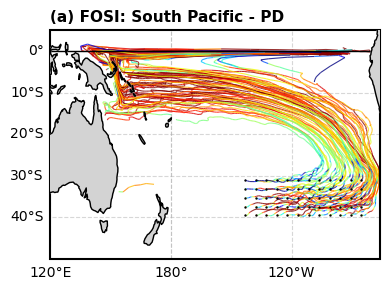

In [99]:
da = da_f
lon_data= lon_trunc_f[:, 0:244]
lat_data= lat_trunc_f[:, 0:244]
z_data= z_trunc_f[:, 0:244]
region_idx = region_idx_f

fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

####### INITIAL LOCATIONS
ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

# # #### CONTOURF AND CONTOUR
# contourf_plot = da.plot.contourf(
#     x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
#     levels=11, vmax=60e-5, vmin=0, alpha=1) # 60 for SH

#### TRAJECTORIES
for ind in range(60):
    print(ind)
    i = region_idx[::1][ind]
    lon = lon_data.isel(trajectory=i).values
    lat = lat_data.isel(trajectory=i).values
    depth = FOSI_pd_obs_array[ind,:]#z_data.isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='jet', norm=plt.Normalize(1.025, 1.026), 
            linewidth=.8, alpha=0.8, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

#### TITLE
# plt.title('(f) FOSI \n30°S to 45°S, 215°E to 275°E', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.title('(a) FOSI: South Pacific - PD', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

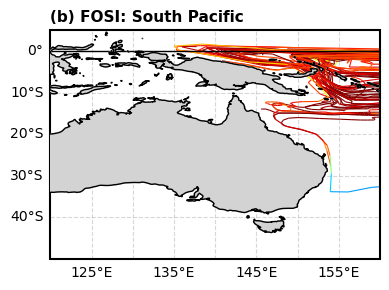

In [70]:
da = da_f
lon_data= lon_trunc_f[:, 0:244]
lat_data= lat_trunc_f[:, 0:244]
z_data= z_trunc_f[:, 0:244]
region_idx = region_idx_f

fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
# ax.set_extent([120, 160, -50, 5], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

####### INITIAL LOCATIONS
ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

# # #### CONTOURF AND CONTOUR
# contourf_plot = da.plot.contourf(
#     x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
#     levels=11, vmax=60e-5, vmin=0, alpha=1) # 60 for SH

#### TRAJECTORIES
for i in region_idx[::1]:
    lon = lon_data.isel(trajectory=i).values
    lat = lat_data.isel(trajectory=i).values
    depth = z_data.isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='jet', norm=plt.Normalize(0, 25000), 
            linewidth=.8, alpha=1, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

#### TITLE
# plt.title('(f) FOSI \n30°S to 45°S, 215°E to 275°E', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.title('(b) FOSI: South Pacific', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

In [32]:
# LENS --- South Pacific
ENS_MEMBERS_LIST = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49] 
INIT_DEPTH = 50

region_indx_list = []; da_list = []
lon_trunc_list = []; lat_trunc_list = []; z_trunc_list = []

for ENS_MEMB in ENS_MEMBERS_LIST:
    file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_lens{}_SH_startingat{}m_1958_1977.zarr'.format(
        ENS_MEMB, INIT_DEPTH)

    lens_pt = xr.open_zarr(file_path)
    l_time, l_lon, l_lat, l_z = compute_data(lens_pt)
    print(ENS_MEMB)
    
    # ### SOUTH PACIFIC
    # da_l, region_idx_l,lon_trunc_l,lat_trunc_l, z_trunc_l = calc_density(
    #    lon_data=l_lon, lat_data=l_lat, z_data=l_z, 
    #     lat_min=-40, lat_max=-30, lon_min=220, lon_max=240,
    #     timestart=0, timeend=244)

    ### SOUTH PACIFIC
    da_l, region_idx_l,lon_trunc_l,lat_trunc_l, z_trunc_l = calc_density(
       lon_data=l_lon, lat_data=l_lat, z_data=l_z, 
        lat_min=-40, lat_max=-30, lon_min=215, lon_max=275, # 220 to 240
    # timestart=0, timeend=244)
    timestart=244-61, timeend=244)

    
    region_indx_list.append(region_idx_l)
    lon_trunc_list.append(lon_trunc_l)
    lat_trunc_list.append(lat_trunc_l)
    z_trunc_list.append(z_trunc_l)
    da_list.append(da_l)

0
65
32
85
61
90
80
68
73
49


In [44]:
LENS61_pd_obs_array = np.load('/glade/derecho/scratch/cassiacai/LENS_SH61_traj_PD_fullarray.npy')


In [67]:
LENS61_pd_obs_array.shape

(60, 244)

In [87]:
original_array = np.linspace(0, 20, 244)

array_2d = np.tile(original_array, (60, 1))
ceil_array = np.ceil(array_2d).astype(int)


In [ ]:
da = da_f
lon_data= lon_trunc_f[:, 0:244]
lat_data= lat_trunc_f[:, 0:244]
z_data= z_trunc_f[:, 0:244]
region_idx = region_idx_f

fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

####### INITIAL LOCATIONS
ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

# # #### CONTOURF AND CONTOUR
# contourf_plot = da.plot.contourf(
#     x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
#     levels=11, vmax=60e-5, vmin=0, alpha=1) # 60 for SH

#### TRAJECTORIES
for ind in range(60):
    i = region_idx[::1][ind]
    lon = lon_data.isel(trajectory=i).values
    lat = lat_data.isel(trajectory=i).values
    depth = ceil_array[ind,:]#z_data.isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='brg', norm=plt.Normalize(0, 20), 
            linewidth=.8, alpha=0.8, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

#### TITLE
# plt.title('(f) FOSI \n30°S to 45°S, 215°E to 275°E', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.title('(d) FOSI: South Pacific - Timing', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

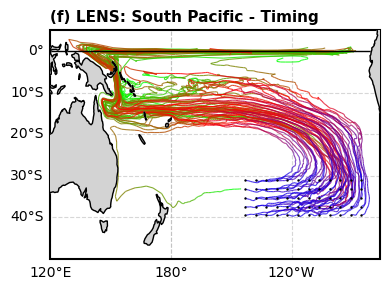

In [95]:
da = da_xr.mean(dim='ensemble')
lon_data= lon_trunc_list[4][ :, 0:244]
lat_data= lat_trunc_list[4][:, 0:244]
z_data= z_trunc_list[4][:, 0:244]
region_idx = region_indx_list[0]

fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

####### INITIAL LOCATIONS
ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

# # #### CONTOURF AND CONTOUR
# contourf_plot = da.plot.contourf(
#     x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
#     levels=11, vmax=60e-5, vmin=0, alpha=1) # 60 for SH

#### TRAJECTORIES
for ind in range(60):
    i = region_idx[::1][ind]
    lon = lon_data.isel(trajectory=i).values
    lat = lat_data.isel(trajectory=i).values
    depth = ceil_array[ind,:]#z_data.isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='brg', norm=plt.Normalize(0, 20), 
            linewidth=.8, alpha=0.8, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

#### TITLE
# plt.title('(f) FOSI \n30°S to 45°S, 215°E to 275°E', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.title('(f) LENS: South Pacific - Timing', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59


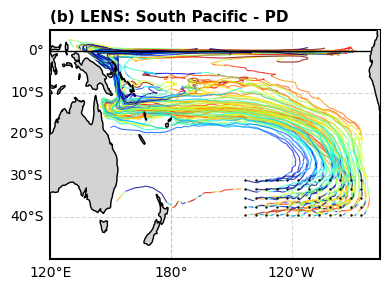

In [100]:
da = da_xr.mean(dim='ensemble')
lon_data= lon_trunc_list[4][ :, 0:244]
lat_data= lat_trunc_list[4][:, 0:244]
z_data= z_trunc_list[4][:, 0:244]
region_idx = region_indx_list[0]

fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

####### INITIAL LOCATIONS
ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

# # #### CONTOURF AND CONTOUR
# contourf_plot = da.plot.contourf(
#     x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
#     levels=11, vmax=60e-5, vmin=0, alpha=1) # 60 for SH

#### TRAJECTORIES
for ind in range(60):
    print(ind)
    i = region_idx[::1][ind]
    lon = lon_data.isel(trajectory=i).values
    lat = lat_data.isel(trajectory=i).values
    depth = LENS61_pd_obs_array[ind,:]#z_data.isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='jet', norm=plt.Normalize(1.025, 1.026), 
            linewidth=.8, alpha=0.8, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

#### TITLE
# plt.title('(f) FOSI \n30°S to 45°S, 215°E to 275°E', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.title('(b) LENS: South Pacific - PD', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()

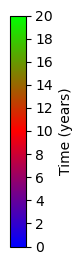

In [131]:
fig, (ax1) = plt.subplots(1, 1, figsize=(0.2, 3))

# Blues colorbar
density_sm1 = plt.cm.ScalarMappable(cmap='brg', norm=plt.Normalize(0, 20))
cbar1 = plt.colorbar(density_sm1, cax=ax1, orientation='vertical')
cbar1.set_label('Time (years)', fontsize=10)
tick_values1 = np.linspace(0, 20, 11)  # 0, 0.5, 1.0, 1.5, 2.0
cbar1.set_ticks(tick_values1)
cbar1.set_ticklabels([f'{x:.0f}' for x in tick_values1])
cbar1.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

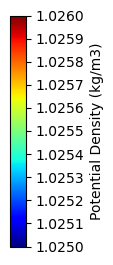

In [128]:
fig, (ax1) = plt.subplots(1, 1, figsize=(0.2, 3))

# Blues colorbar
density_sm1 = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(1.025, 1.026))
cbar1 = plt.colorbar(density_sm1, cax=ax1, orientation='vertical')
cbar1.set_label('Potential Density (kg/m3)', fontsize=10)
tick_values1 = np.linspace(1.025, 1.026, 11)  # 0, 0.5, 1.0, 1.5, 2.0
cbar1.set_ticks(tick_values1)
cbar1.set_ticklabels([f'{x:.04f}' for x in tick_values1])
cbar1.ax.tick_params(labelsize=10)

plt.tight_layout()
plt.show()

In [119]:
np.linspace(1.025, 1.026, 11)

array([1.025 , 1.0251, 1.0252, 1.0253, 1.0254, 1.0255, 1.0256, 1.0257,
       1.0258, 1.0259, 1.026 ])

In [30]:
# # LENS --- North Pacific
# ENS_MEMBERS_LIST = [0, 65,  32, 85, 61, 90, 80, 68, 73, 49] 
# INIT_DEPTH = 5

# region_indx_list = []; da_list = []
# lon_trunc_list = []; lat_trunc_list = []; z_trunc_list = []

# for ENS_MEMB in ENS_MEMBERS_LIST:
#     print(ENS_MEMB)
#     file_path = '/glade/derecho/scratch/cassiacai/particle_trajectories/particle_trajectories_lens{}_NH_startingat{}m_1958_1977.zarr'.format(
#         ENS_MEMB, INIT_DEPTH)

#     lens_pt = xr.open_zarr(file_path)
#     l_time, l_lon, l_lat, l_z = compute_data(lens_pt)

#     ### NORTH PACIFIC
#     da_l, region_idx_l,lon_trunc_l,lat_trunc_l, z_trunc_l = calc_density(
#        lon_data=l_lon, lat_data=l_lat, z_data=l_z, 
#         lat_min=38, lat_max=45, lon_min=140, lon_max=210,
#         timestart=244-61, timeend=244)
    
#     region_indx_list.append(region_idx_l)
#     lon_trunc_list.append(lon_trunc_l)
#     lat_trunc_list.append(lat_trunc_l)
#     z_trunc_list.append(z_trunc_l)
#     da_list.append(da_l)

#     # #### Leakage into the Indian Ocean
#     # lon_data = l_lon
#     # lat_data = l_lat
#     # region_idx = region_idx_l
    
#     # no_in_indotf = len(xr.where(lon_data[region_idx, :].min(axis=1) < 100, 1., np.nan).dropna(dim='trajectory'))
#     # perc = (no_in_indotf / len(region_idx))*100
#     # print(perc)

In [64]:
# # LENS - leakage into the Indian Ocean (West of 110°E)
# leakage_50m = [11.666666666666666, 15.0, 5.0, 5.0, 11.666666666666666, 13.333333333333334, 5.0, 18.333333333333332, 15., 11.666666666666666]
# print(np.mean(leakage_50m))
# print(np.std(leakage_50m))

# leakage_5m = [5., 6.7, 1.7, 1.7, 5., 6.7, 15., 3.3, 8.3]
# print(np.mean(leakage_5m))
# print(np.std(leakage_5m))

In [52]:
da_xr = xr.concat(da_list, dim='ensemble')

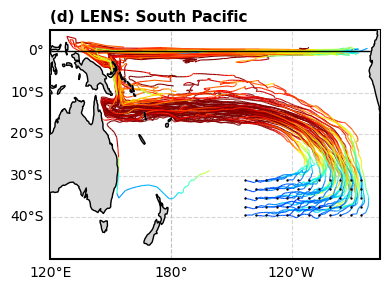

In [34]:
da = da_xr.mean(dim='ensemble')
lon_data= lon_trunc_list[4][ :, 0:244]
lat_data= lat_trunc_list[4][:, 0:244]
z_data= z_trunc_list[4][:, 0:244]
region_idx = region_indx_list[0]

fig, ax = plt.subplots(figsize=(4, 3),
                      subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180, globe=None)})
####### STATICS
ax.add_feature(cfeature.LAND, color='lightgray', zorder=100)
ax.add_feature(cfeature.COASTLINE, linewidth=1., zorder=100)
ax.grid(c='k', linestyle='dashed', alpha=0.2, zorder=4)
ax.set_extent([120, 284, -50, 5], crs=ccrs.PlateCarree())
# ax.set_extent([120, 284, -5, 50], crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels={'left': True, 'bottom': True, 'right': False, 'top': False}, 
                  zorder=4, linestyle='--', alpha=0.5)
gl.xlabel_style = {'size': 10, 'color':'k'}  # Longitude labels
gl.ylabel_style = {'size': 10, 'color':'k'}  # Latitude labels
ax.axhline(y=0, color='k', linestyle='-', linewidth=1, zorder=5)
ax.spines['geo'].set_edgecolor('black')
ax.spines['geo'].set_linewidth(1.5)
ax.set_aspect('auto')

ax.scatter(lon_data[region_idx, 0], lat_data[region_idx, 0], 
           s=0.5, c='k', marker='o', edgecolor='k', zorder=100,transform=ccrs.PlateCarree())

# # #### CONTOURF AND CONTOUR
# contourf_plot = da.plot.contourf(
#     x='lon', y='lat', cmap='Blues', add_colorbar=False, transform=ccrs.PlateCarree(),
#     levels=11, vmax=60e-5, vmin=0, alpha=1) # 60 for SH

#### TRAJECTORIES
for i in region_indx_list[5][::1]:
    lon = lon_trunc_list[5].isel(trajectory=i).values
    lat = lat_trunc_list[5].isel(trajectory=i).values
    depth = z_trunc_list[5].isel(trajectory=i).values
    points = np.array([lon, lat]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    lc = mcollections.LineCollection(
            segments, cmap='jet', norm=plt.Normalize(0, 25000), 
            linewidth=0.8, alpha=1, transform=ccrs.PlateCarree())
    lc.set_array(depth[:-1])
    ax.add_collection(lc)

# #### COLORBAR
# density_sm = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(0.5e-5, 80.5e-5))
# density_sm.set_array([])
# density_cbar = plt.colorbar(density_sm, ax=ax, aspect=30, shrink=0.8, pad=0.1, orientation='horizontal')
# density_cbar.set_label('Normalized Trajectory Density', fontsize=11)
# tick_values = np.arange(0, 90, 20)  # This gives 5, 10, 15, 20, 25, 30
# density_cbar.set_ticks(tick_values * 1e-5)
# density_cbar.set_ticklabels([f'{x}' for x in tick_values])  # Shows as 5, 10, 15, etc.
# density_cbar.ax.tick_params(labelsize=12)

#### TITLE
# plt.title('LENS: South Pacific \n25°S to 45°S, 250°E to 275°E', fontsize=11, fontweight='bold', zorder=12, loc='left')

plt.title('(d) LENS: South Pacific', fontsize=11, fontweight='bold', zorder=12, loc='left')
plt.tight_layout()
plt.show()